In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
## titanic dataset에 대한 요약 통계량
df = sns.load_dataset("titanic")
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


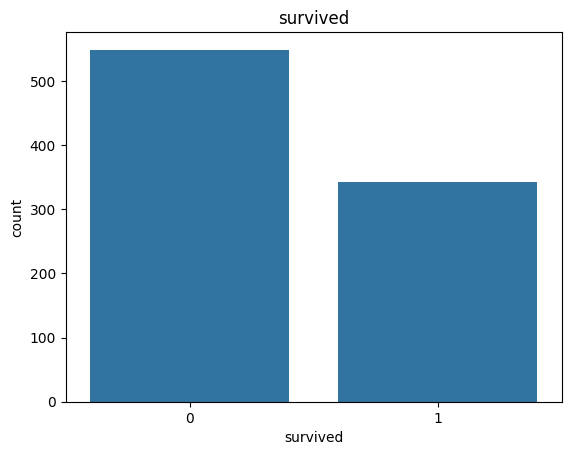

In [3]:
## 생존과 관련된 피처들의 분포 파악
## y값: 우리에게 정답을 알려주는 값으로 상당히 중요
## class가 균형, 불균형인 경우 있음 -> class의 분포를 사전에 확인해야됨!!

## 번주형 변수의 빈도를 막대그래프로 시각화
sns.countplot(data=df, x='survived')
plt.title('survived')
plt.show()

## y값과 pclass, sex, age 관계를 통해 class에 대한 힌트 찾기

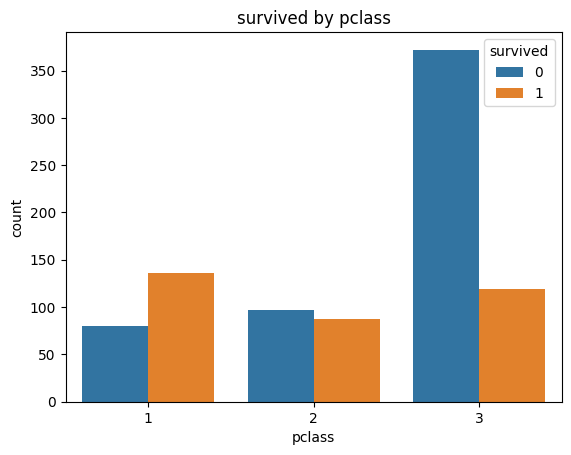

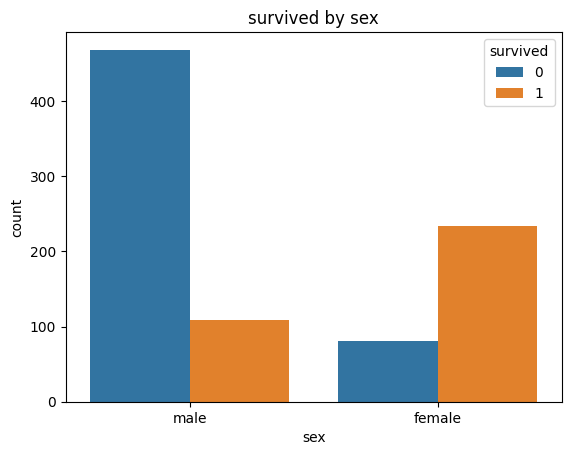

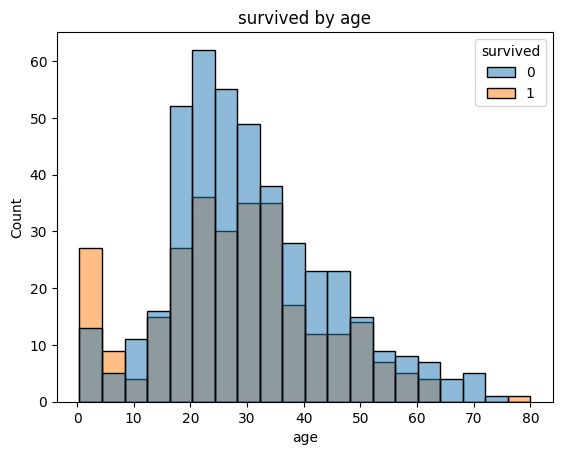

In [6]:
## pclass에 따른 생존 여부 시각화
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('survived by pclass')
plt.show()

## sex에 따른 생존 여부 시각화
sns.countplot(data=df, x='sex', hue='survived')
plt.title('survived by sex')
plt.show()

## age에 따른 생존 여부 시각화
sns.histplot(data=df, x='age', hue='survived')
plt.title('survived by age')
plt.show()

In [12]:
## 결측치 확인
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [14]:
## 간단하게 평균값, 빈도가 높은 값(최빈값), 삭제 방법으로 결측치 대체
df['age'].fillna(df['age'].mean(), inplace=True)  # 평균으로 대체
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)  # 최빈값으로 대체
df.drop(columns = ['deck'], inplace=True)  # 결측률이 높은 유사한 or 의미없는 컬럼은 삭제

/tmp/ipython-input-14-1455138993.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)  # 평균으로 대체
/tmp/ipython-input-14-1455138993.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [15]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [16]:
## feature engineering
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

## 연령대 구분
df['age_group'] = pd.cut(df['age'], bins=[0,9,12,35,60,100], labels=['child','teen','adult','middle','senior'])

## 요금 구분
df['fare_group'] = pd.qcut(df['fare'], 4, labels=['low','mid','high','vghigh'])

## 범주형 변수 인코딩
df = pd.get_dummies(df, columns=['sex','embarked','age_group','fare_group'], drop_first=True)

In [18]:
df.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'embark_town', 'alive', 'alone', 'family_size',
       'is_alone', 'sex_male', 'embarked_Q', 'embarked_S', 'age_group_teen',
       'age_group_adult', 'age_group_middle', 'age_group_senior',
       'fare_group_mid', 'fare_group_high', 'fare_group_vghigh'],
      dtype='object')

In [19]:
df

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_size,is_alone,sex_male,embarked_Q,embarked_S,age_group_teen,age_group_adult,age_group_middle,age_group_senior,fare_group_mid,fare_group_high,fare_group_vghigh
0,0,3,22.000000,1,0,7.2500,Third,man,True,Southampton,no,False,2,0,True,False,True,False,True,False,False,False,False,False
1,1,1,38.000000,1,0,71.2833,First,woman,False,Cherbourg,yes,False,2,0,False,False,False,False,False,True,False,False,False,True
2,1,3,26.000000,0,0,7.9250,Third,woman,False,Southampton,yes,True,1,1,False,False,True,False,True,False,False,True,False,False
3,1,1,35.000000,1,0,53.1000,First,woman,False,Southampton,yes,False,2,0,False,False,True,False,True,False,False,False,False,True
4,0,3,35.000000,0,0,8.0500,Third,man,True,Southampton,no,True,1,1,True,False,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,Second,man,True,Southampton,no,True,1,1,True,False,True,False,True,False,False,True,False,False
887,1,1,19.000000,0,0,30.0000,First,woman,False,Southampton,yes,True,1,1,False,False,True,False,True,False,False,False,True,False
888,0,3,29.699118,1,2,23.4500,Third,woman,False,Southampton,no,False,4,0,False,False,True,False,True,False,False,False,True,False
889,1,1,26.000000,0,0,30.0000,First,man,True,Cherbourg,yes,True,1,1,True,False,False,False,True,False,False,False,True,False


In [20]:
## 사용할 피처들 정의
features = ['pclass','family_size','is_alone','embarked_Q','embarked_S',
            'age_group_teen','age_group_adult', 'age_group_middle', 'age_group_senior',
            'fare_group_mid', 'fare_group_high', 'fare_group_vghigh']

In [21]:
features

['pclass',
 'family_size',
 'is_alone',
 'embarked_Q',
 'embarked_S',
 'age_group_teen',
 'age_group_adult',
 'age_group_middle',
 'age_group_senior',
 'fare_group_mid',
 'fare_group_high',
 'fare_group_vghigh']

## 전처리된 titanic dataset을 바탕으로 ML 분석

In [22]:
## 데이터를 모델에 학습 시켜야 한다
## 데이터 분할 -> train/test or train/test/valid 분할

## 데이터 정의
X = df[features] * 1
y = df['survived']

## 데이터 train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=111)

## 모델 정의 및 학습
model = LogisticRegression(max_iter=1000)  # 반복 횟수를 늘려서 수렴이 잘 되도록 설정
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
## 예측 수행
y_pred = model.predict(X_test)

## 모델 평가
## accuracy_score, confusion_matrix, classification_report
print('정확도:', accuracy_score(y_test, y_pred)) # 72% 정확도
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

정확도: 0.7150837988826816
[[93 20]
 [31 35]]
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       113
           1       0.64      0.53      0.58        66

    accuracy                           0.72       179
   macro avg       0.69      0.68      0.68       179
weighted avg       0.71      0.72      0.71       179



In [27]:
## 머신이 예측한 값
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0])

In [28]:
#실제값
np.array(y_test)

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [29]:
len(y_pred)

179

In [30]:
len(y_test)

179

In [31]:
X_test

,pclass,family_size,is_alone,embarked_Q,embarked_S,age_group_teen,age_group_adult,age_group_middle,age_group_senior,fare_group_mid,fare_group_high,fare_group_vghigh
374,3,5,0,0,1,0,0,0,0,0,1,0
211,2,1,1,0,1,0,1,0,0,0,1,0
258,1,1,1,0,0,0,1,0,0,0,0,1
584,3,1,1,0,0,0,1,0,0,1,0,0
461,3,1,1,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
739,3,1,1,0,1,0,1,0,0,0,0,0
323,2,3,0,0,1,0,1,0,0,0,1,0
395,3,1,1,0,1,0,1,0,0,0,0,0
386,3,8,0,0,1,0,0,0,0,0,0,1


In [32]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [33]:
X

,pclass,family_size,is_alone,embarked_Q,embarked_S,age_group_teen,age_group_adult,age_group_middle,age_group_senior,fare_group_mid,fare_group_high,fare_group_vghigh
0,3,2,0,0,1,0,1,0,0,0,0,0
1,1,2,0,0,0,0,0,1,0,0,0,1
2,3,1,1,0,1,0,1,0,0,1,0,0
3,1,2,0,0,1,0,1,0,0,0,0,1
4,3,1,1,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,1,1,0,1,0,1,0,0,1,0,0
887,1,1,1,0,1,0,1,0,0,0,1,0
888,3,4,0,0,1,0,1,0,0,0,1,0
889,1,1,1,0,0,0,1,0,0,0,1,0


## LogisticRegression Model이 예측에 어떤 feature를 더 중요하게 사용했는지 시각적으로 확인
- 모델이 예측했을 때 어떤 피처들을 더 가중치 있게 봤는지?
- feature_importances_ , model.coef_
- 계수가 양수이면 생존 쪽에 영향을 주는 요인, 음수이면 사망 쪽에 영향을 주는 요인

<Axes: >

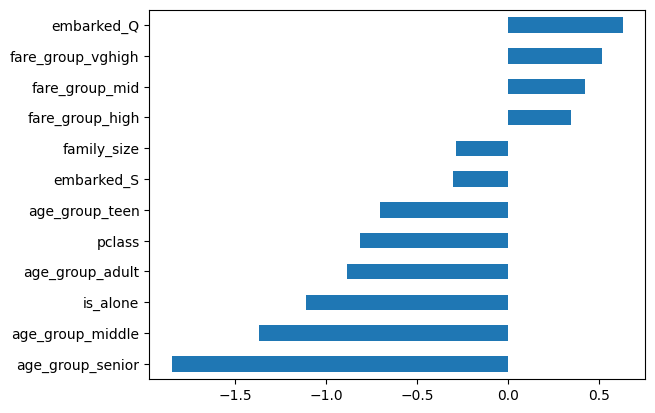

In [26]:
## model의 계수 추출 및 series 생성
coefficients = pd.Series(model.coef_[0], index=features)

## 중요도 순으로 정렬
coefficients_sorted = coefficients.sort_values()

## 수평 막대그래프 시각화
coefficients_sorted.plot(kind='barh')

## 그림 해석
- is_alone : 음수, 사망 쪽에 영향을 주는 요인
  - 혼자일수록 생존 가능성 ↘
- age_group_senior : 음수, 사망 쪽에 영향을 주는 요인
  - 나이가 많을수록 생존 가능성 ↘
- embarked_S : 양수, 생존 쪽에 영향을 주는 요인
  - S항구에서 탄 사람일수록 생존 가능성 ↗